Neural networks are computational models inspired by the human brain, designed to recognize patterns and solve complex tasks such as classification, regression and generation.

PyTorch offers two primary methods for building neural networks:
- **Using nn.Module:** To create a custom network, subclass the nn.Module class and define the __init__ and forward functions. The __init__ method sets up the layers and parameters, while the forward function defines how input flows through the network and produces output.
- **Using nn.Sequential:** This container allows you to specify layers in a list. The layers are automatically connected in the order provided.

# Implementing Feedforward Neural Network for MNIST using PyTorch
Let's implement a Feedforward Neural Network (FNN) for classifying handwritten digits from the MNIST dataset using PyTorch.

#### Step 1: Import the Necessary Libraries
We start by importing the necessary PyTorch libraries, which include torch, torch.nn for building the model, torch.optim for the optimizer and torchvision for dataset handling and image transformations.

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

#### Step 2: Define Hyperparameters and Transformations
We set hyperparameters like batch_size, num_epochs and learning_rate for training. A transformation pipeline is applied to MNIST images: converting them to tensors and normalizing the pixel values.

In [9]:
batch_size = 64
num_epochs = 10
learning_rate = 0.01

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

#### Step 3: Load and Prepare the Dataset
The MNIST dataset is loaded for both training and testing. We use DataLoader to manage batching and shuffling of data during training.

In [10]:
train_dataset = datasets.MNIST(
    root='.', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(
    root='.', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=True)

#### Step 4: Define the Neural Network Model
We define a simple feedforward neural network with two fully connected layers. The first layer takes the flattened image (28x28 pixels) and outputs 512 features. The second layer outputs 10 classes (digits 0-9).

In [11]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

#### Step 5: Define the Loss Function, Optimizer and Model Instance
We use CrossEntropyLoss as the loss function for **multi-class classification**. The optimizer used is **Stochastic Gradient Descent (SGD)**.

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

#### Step 6: Define the Training and Test Loops
The training loop processes the batches, computes the gradients and updates the model parameters. The test loop evaluates the model on the test dataset.

In [13]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    return torch.sum(preds == labels).item() / len(labels)

def train(model, device, train_loader, criterion, optimizer, epoch):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += accuracy(outputs, labels)
        if(i + 1) % 200 == 0:
            print(
                f"Epoch {epoch}, Batch {i +1}, Loss: {running_loss / 200:.4f}, Accuracy: {running_acc / 200:.4f}")
            running_loss = 0.0
            running_acc = 0.0

def test(model, device, test_loader, criterion):
    model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            test_acc += accuracy(outputs, labels)
            print(
            f'Test Loss: {test_loss / len(test_loader):.4f}, Test Accuracy: {test_acc / len(test_loader):.4f}')

#### Step 7: Train, Test and Visualize Results
The model is trained for a set number of epochs and then tested. Additionally, a few sample predictions are visualized using matplotlib.

Epoch 1, Batch 200, Loss: 0.1054, Accuracy: 0.9702
Epoch 1, Batch 400, Loss: 0.1062, Accuracy: 0.9709
Epoch 1, Batch 600, Loss: 0.1015, Accuracy: 0.9735
Epoch 1, Batch 800, Loss: 0.1090, Accuracy: 0.9701
Test Loss: 0.0004, Test Accuracy: 0.0062
Test Loss: 0.0008, Test Accuracy: 0.0125
Test Loss: 0.0019, Test Accuracy: 0.0186
Test Loss: 0.0029, Test Accuracy: 0.0247
Test Loss: 0.0033, Test Accuracy: 0.0310
Test Loss: 0.0039, Test Accuracy: 0.0372
Test Loss: 0.0045, Test Accuracy: 0.0435
Test Loss: 0.0052, Test Accuracy: 0.0496
Test Loss: 0.0066, Test Accuracy: 0.0555
Test Loss: 0.0075, Test Accuracy: 0.0617
Test Loss: 0.0081, Test Accuracy: 0.0679
Test Loss: 0.0097, Test Accuracy: 0.0735
Test Loss: 0.0100, Test Accuracy: 0.0799
Test Loss: 0.0112, Test Accuracy: 0.0858
Test Loss: 0.0117, Test Accuracy: 0.0920
Test Loss: 0.0125, Test Accuracy: 0.0979
Test Loss: 0.0127, Test Accuracy: 0.1043
Test Loss: 0.0134, Test Accuracy: 0.1103
Test Loss: 0.0139, Test Accuracy: 0.1165
Test Loss: 0.0147

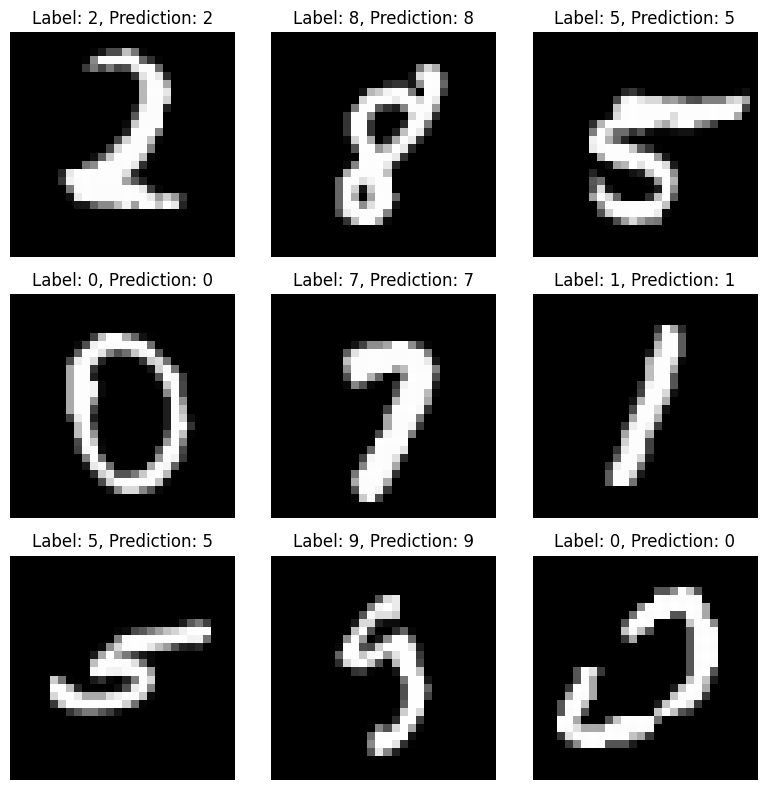

In [15]:
for epoch in range(1, num_epochs + 1):
    train(model, device, train_loader, criterion, optimizer, epoch)
    test(model, device, test_loader, criterion)

samples, labels = next(iter(test_loader))
samples = samples.to(device)
outputs = model(samples)
_, preds = torch.max(outputs, 1)

samples = samples.cpu().numpy()
fig, axes = plt.subplots(3, 3, figsize=(8, 8))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(samples[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i]}, Prediction: {preds[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()
